In [12]:
# %matplotlib ipympl
from wavesongs.object import Syllable, Song, Synthetic
from wavesongs.data.manager import ProjDirs
from wavesongs.utils import plot
from wavesongs.data.download import xc_url

# Functions to generate synthetic data
from wavesongs.core.bird import Model
from wavesongs.core.solver import *

In [138]:
syllable.tlim, times[index], syllable.t0,
time_whole.shape, syllable.s.shape, times[index][0]*syllable.sr

#, syllable.ff.shape,
# syllable.time_s.shape, beta_optimal_rs.shape
times

[(7.51, 7.79),
 (7.94, 8.26),
 (8.38, 8.64),
 (8.72, 8.85),
 (8.88, 8.99),
 (9.03, 9.14),
 (9.17, 9.27),
 (9.31, 9.41),
 (9.44, 9.54),
 (9.59, 9.68)]

Syllable 0: (7.51, 7.79) - Type: theme
Syllable 1: (7.94, 8.26) - Type: theme
Syllable 2: (8.38, 8.64) - Type: theme
Syllable 3: (8.72, 8.85) - Type: trill
Syllable 4: (8.88, 8.99) - Type: trill
Syllable 5: (9.03, 9.14) - Type: trill
Syllable 6: (9.17, 9.27) - Type: trill
Syllable 7: (9.31, 9.41) - Type: trill


Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Note: Illegal Audio-MPEG-Header 0x33292c20 at of

Syllable 8: (9.44, 9.54) - Type: trill
Syllable 9: (9.59, 9.68) - Type: trill


Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


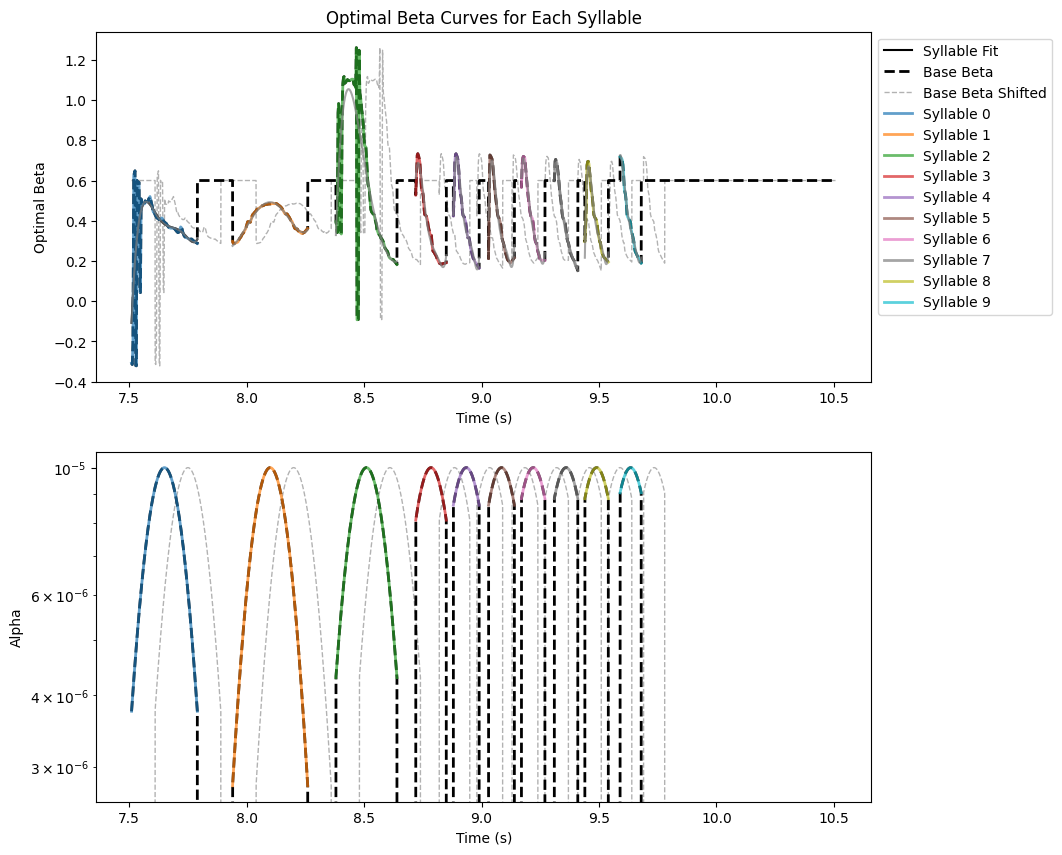

In [178]:
# Compute the optimal beta curve fitting for the syllable
beta_N = 20
syllable = btv
# _, beta_fit = optimal_beta_curve(syllable, model, alpha_0=alpha_0,
#                                           beta_N=beta_N, plot=False, poly_deg=5)
beta_list = []
beta_fit_list = []
times_list = []
scores = []
params = []
alphas = []
umbral_FF = 1.4
n_fft = 512
model = Model()
poly_deg = 5
ff_method = 'yin'
times = metadata["times"]
alpha_0 = 1e-5

beta_bif, mu1_curves, _, _ = model.bifurcation_ode()
alpha_base = -1e-2, 
beta_base = 0.6# beta_bif[(np.abs(mu1_curves[1] - alpha_0)).argmin() + 1]# 1e-9
all_duration = syllable.tlim[1]-syllable.tlim[0]
time_whole = np.arange(0, all_duration, 1/syllable.sr)  # seconds
whole_beta = beta_base * np.ones(syllable.s.shape[0])
whole_alpha = alpha_base * np.ones(syllable.s.shape[0])

for index in range(len(times)):
    print(f"Syllable {index}: {metadata['times'][index]} - Type: {metadata['type'][index]}")
    metadata_indx = {key: metadata[key][index] for key in metadata}
    syllable_i = Syllable(file_id=syllable.file_name, tlim=times[index],
                        proj_dirs=syllable.proj_dirs, metadata=metadata_indx) 
    syllable_i.acoustical_features(umbral_FF=umbral_FF, n_fft=n_fft, ff_method=ff_method)
    
    # Resample optimal beta curve to match the time vector of the syllable
    duration_syl = syllable_i.time_s[-1] - syllable_i.time_s[0]
    alpha = gaussian(syllable_i.time_s, alpha_0, duration_syl/2, sigma=0.1, a1=0)
    beta_curve_interp = interp1d(syllable_i.time, beta_fit(syllable_i.ff), kind='linear', fill_value='extrapolate')
    beta_optimal_rs = beta_curve_interp(syllable_i.time_s)

    beta_fit_poly = Polynomial.fit(syllable_i.time_s, beta_optimal_rs, deg=poly_deg)
    r2_beta_ff = r2_score(beta_optimal_rs, beta_fit_poly(syllable_i.time_s))
    rmse_beta_ff = np.sqrt(mean_squared_error(beta_optimal_rs, beta_fit_poly(syllable_i.time_s)))

    params.append(beta_fit_poly.coef)
    scores.append([r2_beta_ff, rmse_beta_ff])
    beta_list.append(beta_optimal_rs)
    times_list.append(syllable_i.time_s)
    beta_fit_list.append(beta_fit_poly(syllable_i.time_s))
    alphas.append(alpha)

    start_index = int((times[index][0]-times[0][0])*syllable.sr)
    end_index = start_index + syllable_i.s.shape[0]
    whole_alpha[start_index:end_index] = alpha
    whole_beta[start_index:end_index] = beta_optimal_rs  # beta_fit_poly(syllable_i.time_s)# beta_optimal_rs  # or

samples_shifted = 0.1 * syllable.sr # 0.1 seconds
whole_alpha_shifted = np.roll(whole_alpha, samples_shifted)
whole_beta_shifted = np.roll(whole_beta, samples_shifted)
alpha = 0.7

fig, axs = plt.subplots(2, 1, figsize=(10, 10))
axs[0].plot(times_list[0]+times[0][0], beta_fit_list[0], label=f"Syllable Fit", color="k")
axs[0].plot(time_whole + times[0][0], whole_beta, "--", label="Base Beta", color="black", lw=2)
axs[1].semilogy(time_whole + times[0][0], whole_alpha, "--", label="Base Alpha", color="black", lw=2)
axs[0].plot(time_whole + times[0][0], whole_beta_shifted, "--", label="Base Beta Shifted", color="black", lw=1, alpha=0.3)
axs[1].semilogy(time_whole + times[0][0], whole_alpha_shifted, "--", label="Base Alpha Shifted", color="black", lw=1, alpha=0.3)
for i in range(len(beta_list)):
    axs[0].plot(times_list[i]+times[i][0], beta_list[i], label=f"Syllable {i}", lw=2, alpha=alpha)
    axs[0].plot(times_list[i]+times[i][0], beta_fit_list[i], color="gray", alpha=alpha)

    axs[1].semilogy(times_list[i]+times[i][0], alphas[i], label=f"Syllable {i}", lw=2, alpha=alpha)

axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Alpha")

axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Optimal Beta")
axs[0].set_title("Optimal Beta Curves for Each Syllable")
axs[0].legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

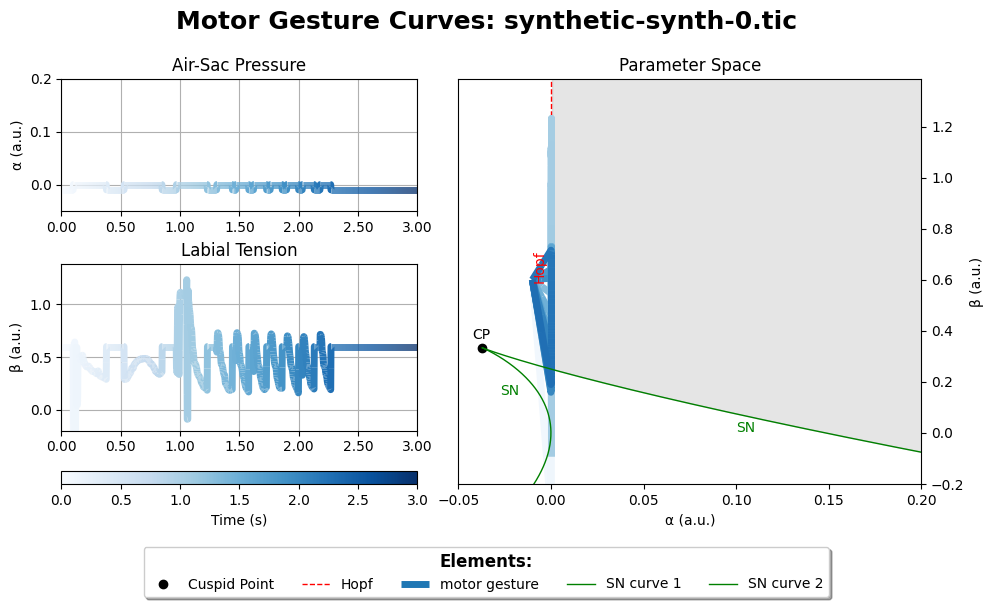

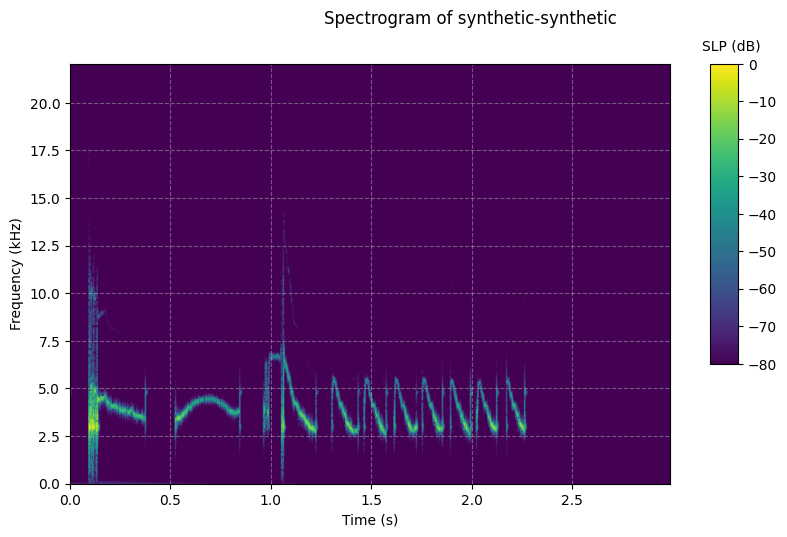

In [179]:
# Best syllable found using the optimal beta and defined alpha0
# Create btv_synth syllable and 
btv_synth = Synthetic(duration=btv.tlim[1]-btv.tlim[0], proj_dirs=btv.proj_dirs)
btv_synth.initialize()

synthetized = model.motor_gesture(btv_synth, curves=[whole_alpha_shifted, whole_beta_shifted])
synthetized.acoustical_features(umbral_FF=1.0, n_fft=512, ff_method="yin")

# Plot the motor gesture and waveform and spectrogram generated
_ = plotter.alpha_beta(synthetized, save=False)
_ = plotter.spectrogram(synthetized, save=False, ff=False)

# Play the synthetized syllable
synthetized.play()

In [175]:
max(synthetized.s)

np.float64(1.0)

Downloaded audio to XC422161 - Rufous-collared Sparrow - Zonotrichia capensis.mp3


Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


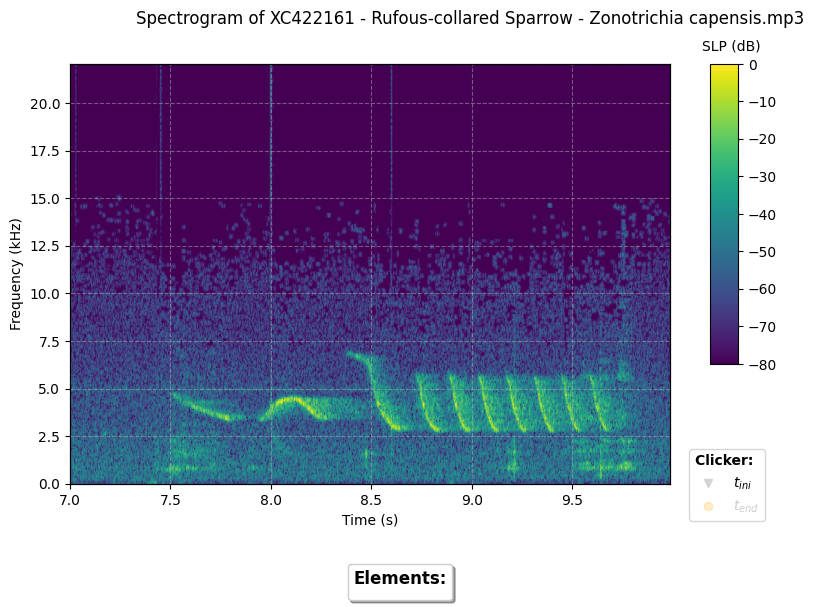

In [155]:
# Download the audio file
file_name = xc_url("https://xeno-canto.org/422161/download")
# Define project directory and plotter objects
proj_dirs = ProjDirs(audios='.')
plotter = plot.set_plotter()

# Define the bem te vi song and compute acoustical features
btv = Song(file_id=file_name , tlim=(7, 10), proj_dirs=proj_dirs) 
btv.acoustical_features(umbral_FF=1.2, n_fft=512, ff_method="yin")
  
# This enables clicking on the spectrogram to get time and frequency values
# Since we are working ina siples example the times were previously clickeed
clicker = plotter.spectrogram(btv, type="2d", ff=False, click="time")
btv.play()

Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


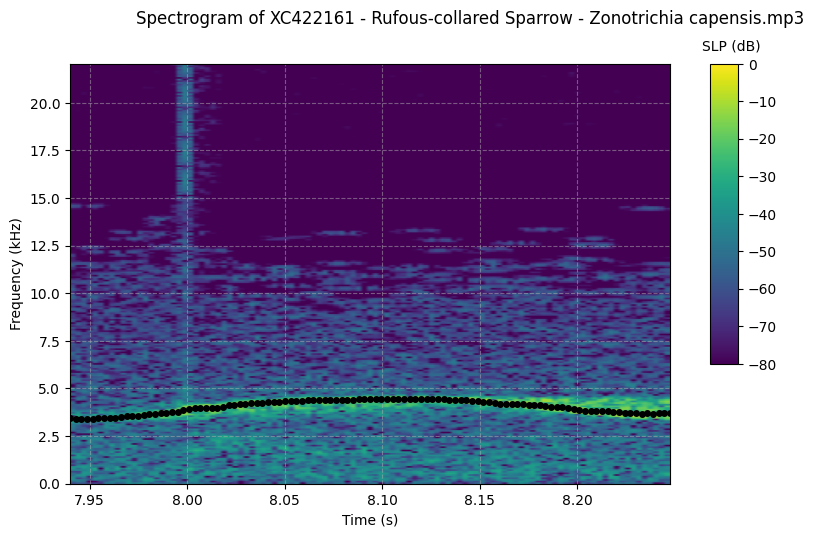

In [10]:
# enable it if you selected the data from the previous cell
# times = plot.get_roi(clicker)
# Second syllable
times = [
    # -------------------- theme ------------- # Syllable No.
    (7.51, 7.79), (7.94, 8.26), (8.38, 8.64),  # 1, 2, 3
    # -------------------- trill -------------
    (8.72, 8.85), (8.88, 8.99), (9.03, 9.14),  # 4, 5, 6
    (9.17, 9.27), (9.31, 9.41), (9.44, 9.54), (9.59, 9.68)  # 7, 8, 9, 10
]
# # First syllable
# times = [
#     # -------------------- theme ------------- # Syllable No.   
#     (2.17, 2.51), (2.56, 2.86), (3.06, 3.24), # 1, 2, 3
#     # -------------------- trill -------------
#     (3.33, 3.43), (3.49, 3.59), (3.63, 3.73),  # 4, 5, 6
#     (3.77, 3.86), (3.91, 4.00), (4.04, 4.12)   # 7, 8, 9
# ]
# Create metadata for the syllables
no_themes, no_trills = 3, 7
metadata = {
  "no_syllable": list(range(0, len(times))),
  "type": ["theme"]*no_themes + ["trill"]*no_trills,
  "class_type": [0]*no_themes + [1]*no_trills,
  "times": times
}

# Create a song using the second syllable, index 1, and compute and plot its acoustical features
index = 1
metadata_indx = {key: metadata[key][index] for key in metadata}
btv_0 = Syllable(file_id=file_name, tlim=times[index], proj_dirs=proj_dirs, metadata=metadata_indx) 
btv_0.acoustical_features(umbral_FF=1.4, n_fft=512, ff_method="yin")
_ = plotter.spectrogram(btv_0, type="2d", ff=True)
btv_0.play()

Computation time for beta vs ff curve: 215.904 s = 3.60 min


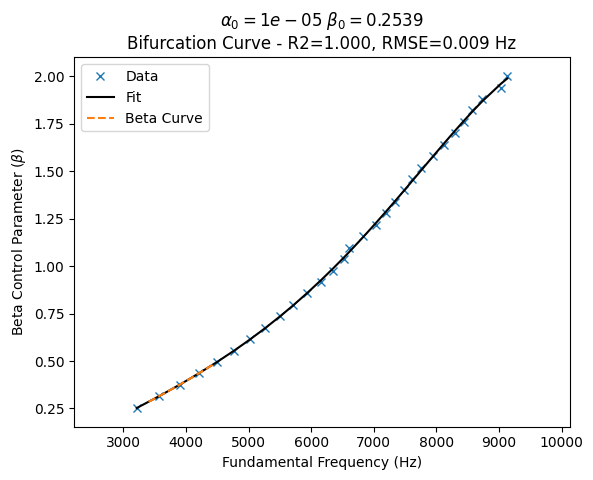

Syllable 0: (7.51, 7.79) - Type: theme
Original song: XC422161 - No. Syllable: 0 - Type: theme


Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


Audio saved at assets/results/audios/augmented/XC422161/0_s0.wav.
Audio saved at assets/results/audios/augmented/XC422161/0_s1.wav.
Audio saved at assets/results/audios/augmented/XC422161/0_s2.wav.
Audio saved at assets/results/audios/augmented/XC422161/0_s3.wav.
Audio saved at assets/results/audios/augmented/XC422161/0_s4.wav.
Audio saved at assets/results/audios/augmented/XC422161/0_s5.wav.
Audio saved at assets/results/audios/augmented/XC422161/0_s6.wav.
Audio saved at assets/results/audios/augmented/XC422161/0_s7.wav.
Audio saved at assets/results/audios/augmented/XC422161/0_s8.wav.
Audio saved at assets/results/audios/augmented/XC422161/0_s9.wav.
Audio saved at assets/results/audios/augmented/XC422161/0_s10.wav.
Audio saved at assets/results/audios/augmented/XC422161/0_s11.wav.
Audio saved at assets/results/audios/augmented/XC422161/0_s12.wav.
Audio saved at assets/results/audios/augmented/XC422161/0_s13.wav.
Audio saved at assets/results/audios/augmented/XC422161/0_s14.wav.
Audio

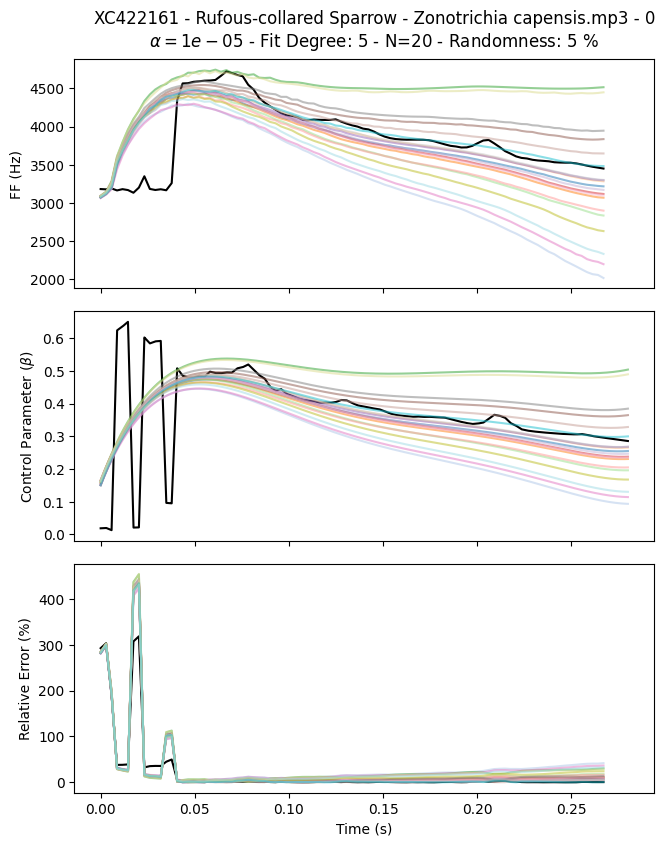

,ME (%),RMSE (Hz),params,alpha,id,file_name,mode,name,type,class_type,no_syllable,times
0,19.883212,752.991806,"[5658.295364106185, -4863.571994231476, 1577.5...",0.00001,0_s0,0_s0.wav,fitting,XC422161,theme,0,0,"(7.51, 7.79)"
1,24.631807,779.444579,"[5658.295364106185, -4863.571994231476, 1577.5...",0.00001,0_s1,0_s1.wav,fitting,XC422161,theme,0,0,"(7.51, 7.79)"
2,37.266206,1063.126591,"[5658.295364106185, -4863.571994231476, 1577.5...",0.00001,0_s2,0_s2.wav,fitting,XC422161,theme,0,0,"(7.51, 7.79)"
3,26.189015,797.348371,"[5658.295364106185, -4863.571994231476, 1577.5...",0.00001,0_s3,0_s3.wav,fitting,XC422161,theme,0,0,"(7.51, 7.79)"
4,23.588087,775.028074,"[5658.295364106185, -4863.571994231476, 1577.5...",0.00001,0_s4,0_s4.wav,fitting,XC422161,theme,0,0,"(7.51, 7.79)"
5,34.917115,983.607791,"[5658.295364106185, -4863.571994231476, 1577.5...",0.00001,0_s5,0_s5.wav,fitting,XC422161,theme,0,0,"(7.51, 7.79)"
6,28.513433,834.833502,"[5658.295364106185, -4863.571994231476, 1577.5...",0.00001,0_s6,0_s6.wav,fitting,XC422161,theme,0,0,"(7.51, 7.79)"
7,25.522922,792.044659,"[5658.295364106185, -4863.571994231476, 1577.5...",0.00001,0_s7,0_s7.wav,fitting,XC422161,theme,0,0,"(7.51, 7.79)"
8,28.182358,825.106142,"[5658.295364106185, -4863.571994231476, 1577.5...",0.00001,0_s8,0_s8.wav,fitting,XC422161,theme,0,0,"(7.51, 7.79)"
9,23.624871,772.842161,"[5658.295364106185, -4863.571994231476, 1577.5...",0.00001,0_s9,0_s9.wav,fitting,XC422161,theme,0,0,"(7.51, 7.79)"


Syllable 1: (7.94, 8.26) - Type: theme
Original song: XC422161 - No. Syllable: 1 - Type: theme


Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


Audio saved at assets/results/audios/augmented/XC422161/1_s0.wav.
Audio saved at assets/results/audios/augmented/XC422161/1_s1.wav.
Audio saved at assets/results/audios/augmented/XC422161/1_s2.wav.
Audio saved at assets/results/audios/augmented/XC422161/1_s3.wav.
Audio saved at assets/results/audios/augmented/XC422161/1_s4.wav.
Audio saved at assets/results/audios/augmented/XC422161/1_s5.wav.
Audio saved at assets/results/audios/augmented/XC422161/1_s6.wav.
Audio saved at assets/results/audios/augmented/XC422161/1_s7.wav.
Audio saved at assets/results/audios/augmented/XC422161/1_s8.wav.
Audio saved at assets/results/audios/augmented/XC422161/1_s9.wav.
Audio saved at assets/results/audios/augmented/XC422161/1_s10.wav.
Audio saved at assets/results/audios/augmented/XC422161/1_s11.wav.
Audio saved at assets/results/audios/augmented/XC422161/1_s12.wav.
Audio saved at assets/results/audios/augmented/XC422161/1_s13.wav.
Audio saved at assets/results/audios/augmented/XC422161/1_s14.wav.
Audio

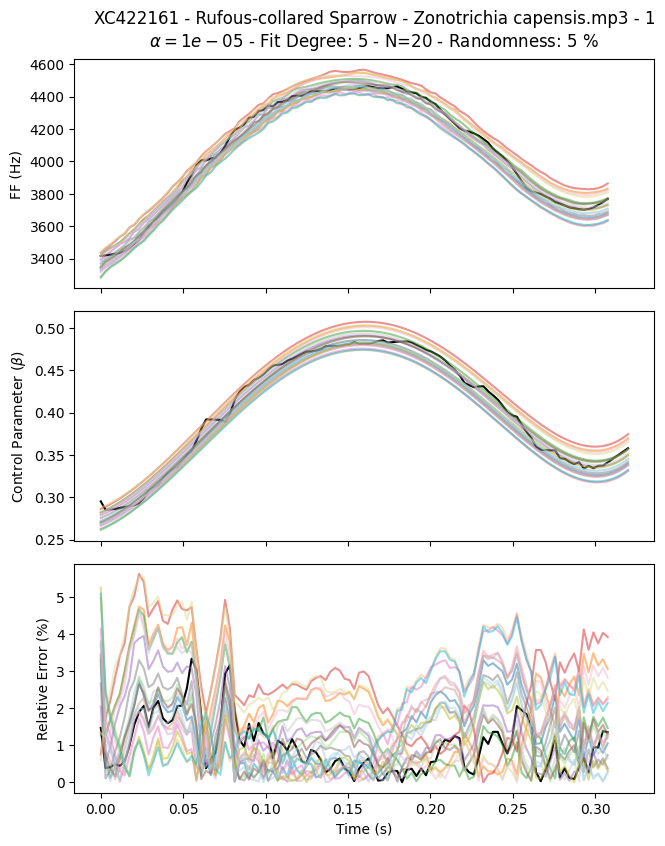

,ME (%),RMSE (Hz),params,alpha,id,file_name,mode,name,type,class_type,no_syllable,times
0,0.981417,47.836111,"[343.45166363665237, 38.77341854015497, -111.7...",0.00001,1_s0,1_s0.wav,fitting,XC422161,theme,0,1,"(7.94, 8.26)"
1,1.332242,64.456700,"[343.45166363665237, 38.77341854015497, -111.7...",0.00001,1_s1,1_s1.wav,fitting,XC422161,theme,0,1,"(7.94, 8.26)"
2,1.172947,56.780520,"[343.45166363665237, 38.77341854015497, -111.7...",0.00001,1_s2,1_s2.wav,fitting,XC422161,theme,0,1,"(7.94, 8.26)"
3,2.104089,93.268819,"[343.45166363665237, 38.77341854015497, -111.7...",0.00001,1_s3,1_s3.wav,fitting,XC422161,theme,0,1,"(7.94, 8.26)"
4,1.821262,89.803701,"[343.45166363665237, 38.77341854015497, -111.7...",0.00001,1_s4,1_s4.wav,fitting,XC422161,theme,0,1,"(7.94, 8.26)"
5,1.586204,74.419284,"[343.45166363665237, 38.77341854015497, -111.7...",0.00001,1_s5,1_s5.wav,fitting,XC422161,theme,0,1,"(7.94, 8.26)"
6,1.087115,50.141446,"[343.45166363665237, 38.77341854015497, -111.7...",0.00001,1_s6,1_s6.wav,fitting,XC422161,theme,0,1,"(7.94, 8.26)"
7,2.640039,114.009418,"[343.45166363665237, 38.77341854015497, -111.7...",0.00001,1_s7,1_s7.wav,fitting,XC422161,theme,0,1,"(7.94, 8.26)"
8,1.377073,68.810383,"[343.45166363665237, 38.77341854015497, -111.7...",0.00001,1_s8,1_s8.wav,fitting,XC422161,theme,0,1,"(7.94, 8.26)"
9,1.360559,63.748017,"[343.45166363665237, 38.77341854015497, -111.7...",0.00001,1_s9,1_s9.wav,fitting,XC422161,theme,0,1,"(7.94, 8.26)"


Syllable 2: (8.38, 8.64) - Type: theme
Original song: XC422161 - No. Syllable: 2 - Type: theme


Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


Audio saved at assets/results/audios/augmented/XC422161/2_s0.wav.
Audio saved at assets/results/audios/augmented/XC422161/2_s1.wav.
Audio saved at assets/results/audios/augmented/XC422161/2_s2.wav.
Audio saved at assets/results/audios/augmented/XC422161/2_s3.wav.
Audio saved at assets/results/audios/augmented/XC422161/2_s4.wav.
Audio saved at assets/results/audios/augmented/XC422161/2_s5.wav.
Audio saved at assets/results/audios/augmented/XC422161/2_s6.wav.
Audio saved at assets/results/audios/augmented/XC422161/2_s7.wav.
Audio saved at assets/results/audios/augmented/XC422161/2_s8.wav.
Audio saved at assets/results/audios/augmented/XC422161/2_s9.wav.
Audio saved at assets/results/audios/augmented/XC422161/2_s10.wav.
Audio saved at assets/results/audios/augmented/XC422161/2_s11.wav.
Audio saved at assets/results/audios/augmented/XC422161/2_s12.wav.
Audio saved at assets/results/audios/augmented/XC422161/2_s13.wav.
Audio saved at assets/results/audios/augmented/XC422161/2_s14.wav.
Audio

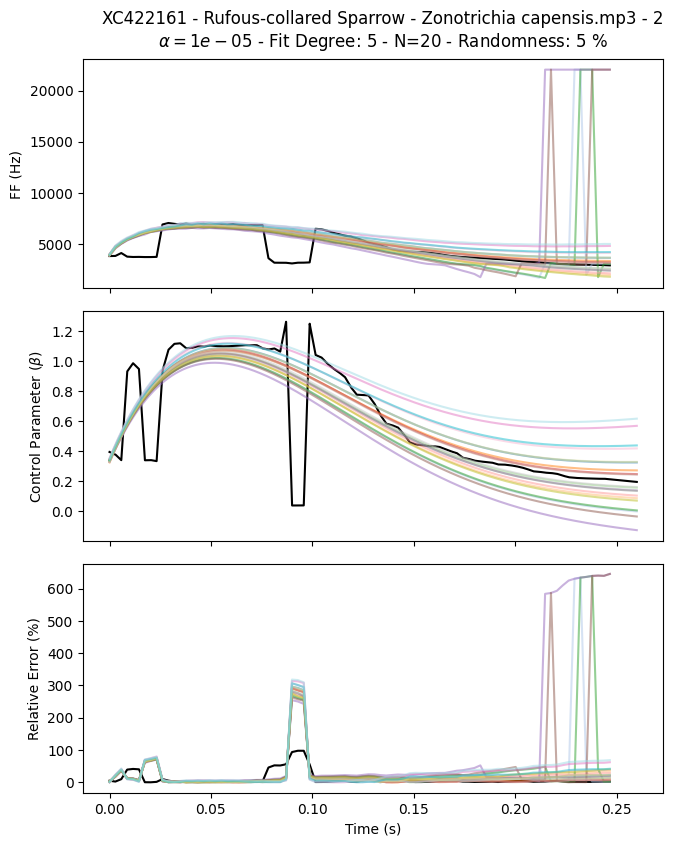

,ME (%),RMSE (Hz),params,alpha,id,file_name,mode,name,type,class_type,no_syllable,times
0,10.450327,1039.949893,"[4947.435063573459, -5550.167315734077, 2360.3...",0.00001,2_s0,2_s0.wav,fitting,XC422161,theme,0,2,"(8.38, 8.64)"
1,21.019919,1084.683001,"[4947.435063573459, -5550.167315734077, 2360.3...",0.00001,2_s1,2_s1.wav,fitting,XC422161,theme,0,2,"(8.38, 8.64)"
2,39.400927,3131.893997,"[4947.435063573459, -5550.167315734077, 2360.3...",0.00001,2_s2,2_s2.wav,fitting,XC422161,theme,0,2,"(8.38, 8.64)"
3,17.955599,1032.757662,"[4947.435063573459, -5550.167315734077, 2360.3...",0.00001,2_s3,2_s3.wav,fitting,XC422161,theme,0,2,"(8.38, 8.64)"
4,24.365023,1118.724506,"[4947.435063573459, -5550.167315734077, 2360.3...",0.00001,2_s4,2_s4.wav,fitting,XC422161,theme,0,2,"(8.38, 8.64)"
5,47.066947,3749.423659,"[4947.435063573459, -5550.167315734077, 2360.3...",0.00001,2_s5,2_s5.wav,fitting,XC422161,theme,0,2,"(8.38, 8.64)"
6,19.236991,1039.351879,"[4947.435063573459, -5550.167315734077, 2360.3...",0.00001,2_s6,2_s6.wav,fitting,XC422161,theme,0,2,"(8.38, 8.64)"
7,17.030203,1035.296492,"[4947.435063573459, -5550.167315734077, 2360.3...",0.00001,2_s7,2_s7.wav,fitting,XC422161,theme,0,2,"(8.38, 8.64)"
8,22.734288,1098.619022,"[4947.435063573459, -5550.167315734077, 2360.3...",0.00001,2_s8,2_s8.wav,fitting,XC422161,theme,0,2,"(8.38, 8.64)"
9,110.895692,7196.990529,"[4947.435063573459, -5550.167315734077, 2360.3...",0.00001,2_s9,2_s9.wav,fitting,XC422161,theme,0,2,"(8.38, 8.64)"


Syllable 3: (8.72, 8.85) - Type: trill
Original song: XC422161 - No. Syllable: 3 - Type: trill


Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


Audio saved at assets/results/audios/augmented/XC422161/3_s0.wav.
Audio saved at assets/results/audios/augmented/XC422161/3_s1.wav.
Audio saved at assets/results/audios/augmented/XC422161/3_s2.wav.
Audio saved at assets/results/audios/augmented/XC422161/3_s3.wav.
Audio saved at assets/results/audios/augmented/XC422161/3_s4.wav.
Audio saved at assets/results/audios/augmented/XC422161/3_s5.wav.
Audio saved at assets/results/audios/augmented/XC422161/3_s6.wav.
Audio saved at assets/results/audios/augmented/XC422161/3_s7.wav.
Audio saved at assets/results/audios/augmented/XC422161/3_s8.wav.
Audio saved at assets/results/audios/augmented/XC422161/3_s9.wav.
Audio saved at assets/results/audios/augmented/XC422161/3_s10.wav.
Audio saved at assets/results/audios/augmented/XC422161/3_s11.wav.
Audio saved at assets/results/audios/augmented/XC422161/3_s12.wav.
Audio saved at assets/results/audios/augmented/XC422161/3_s13.wav.
Audio saved at assets/results/audios/augmented/XC422161/3_s14.wav.
Audio

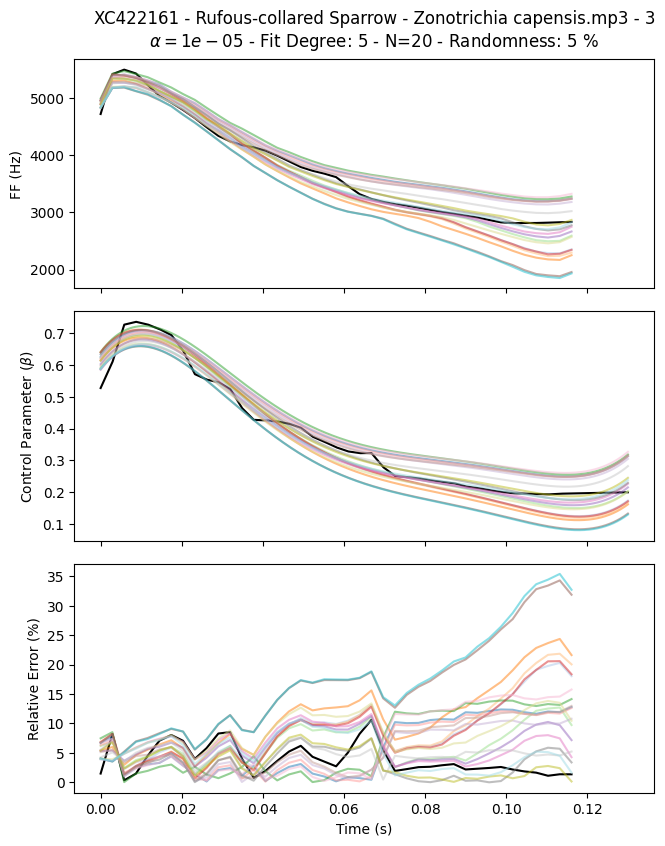

,ME (%),RMSE (Hz),params,alpha,id,file_name,mode,name,type,class_type,no_syllable,times
0,3.930436,205.800116,"[420409.81818105996, -150224.64357130707, 1968...",0.00001,3_s0,3_s0.wav,fitting,XC422161,trill,1,3,"(8.72, 8.85)"
1,5.927647,242.042593,"[420409.81818105996, -150224.64357130707, 1968...",0.00001,3_s1,3_s1.wav,fitting,XC422161,trill,1,3,"(8.72, 8.85)"
2,8.773037,337.372656,"[420409.81818105996, -150224.64357130707, 1968...",0.00001,3_s2,3_s2.wav,fitting,XC422161,trill,1,3,"(8.72, 8.85)"
3,11.196027,421.200947,"[420409.81818105996, -150224.64357130707, 1968...",0.00001,3_s3,3_s3.wav,fitting,XC422161,trill,1,3,"(8.72, 8.85)"
4,8.953325,346.239800,"[420409.81818105996, -150224.64357130707, 1968...",0.00001,3_s4,3_s4.wav,fitting,XC422161,trill,1,3,"(8.72, 8.85)"
5,6.523813,267.628834,"[420409.81818105996, -150224.64357130707, 1968...",0.00001,3_s5,3_s5.wav,fitting,XC422161,trill,1,3,"(8.72, 8.85)"
6,6.477316,260.351602,"[420409.81818105996, -150224.64357130707, 1968...",0.00001,3_s6,3_s6.wav,fitting,XC422161,trill,1,3,"(8.72, 8.85)"
7,8.590649,332.763015,"[420409.81818105996, -150224.64357130707, 1968...",0.00001,3_s7,3_s7.wav,fitting,XC422161,trill,1,3,"(8.72, 8.85)"
8,5.857874,237.540001,"[420409.81818105996, -150224.64357130707, 1968...",0.00001,3_s8,3_s8.wav,fitting,XC422161,trill,1,3,"(8.72, 8.85)"
9,6.418530,265.325587,"[420409.81818105996, -150224.64357130707, 1968...",0.00001,3_s9,3_s9.wav,fitting,XC422161,trill,1,3,"(8.72, 8.85)"


Syllable 4: (8.88, 8.99) - Type: trill
Original song: XC422161 - No. Syllable: 4 - Type: trill


Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


Audio saved at assets/results/audios/augmented/XC422161/4_s0.wav.
Audio saved at assets/results/audios/augmented/XC422161/4_s1.wav.
Audio saved at assets/results/audios/augmented/XC422161/4_s2.wav.
Audio saved at assets/results/audios/augmented/XC422161/4_s3.wav.
Audio saved at assets/results/audios/augmented/XC422161/4_s4.wav.
Audio saved at assets/results/audios/augmented/XC422161/4_s5.wav.
Audio saved at assets/results/audios/augmented/XC422161/4_s6.wav.
Audio saved at assets/results/audios/augmented/XC422161/4_s7.wav.
Audio saved at assets/results/audios/augmented/XC422161/4_s8.wav.
Audio saved at assets/results/audios/augmented/XC422161/4_s9.wav.
Audio saved at assets/results/audios/augmented/XC422161/4_s10.wav.
Audio saved at assets/results/audios/augmented/XC422161/4_s11.wav.
Audio saved at assets/results/audios/augmented/XC422161/4_s12.wav.
Audio saved at assets/results/audios/augmented/XC422161/4_s13.wav.
Audio saved at assets/results/audios/augmented/XC422161/4_s14.wav.
Audio

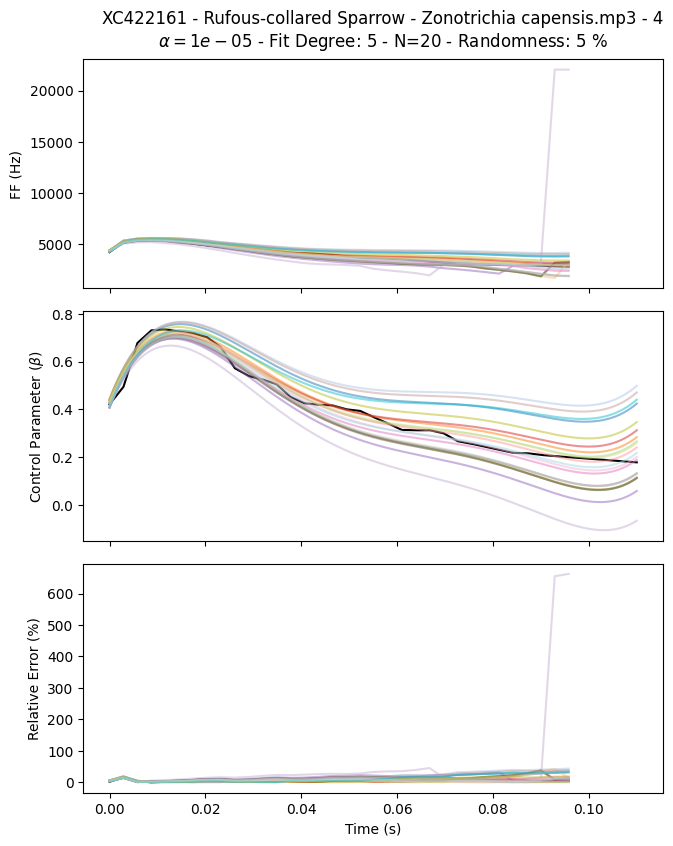

,ME (%),RMSE (Hz),params,alpha,id,file_name,mode,name,type,class_type,no_syllable,times
0,4.868262,256.091107,"[1620122.3506434546, -496819.11215116817, 5622...",0.00001,4_s0,4_s0.wav,fitting,XC422161,trill,1,4,"(8.88, 8.99)"
1,12.372219,528.061178,"[1620122.3506434546, -496819.11215116817, 5622...",0.00001,4_s1,4_s1.wav,fitting,XC422161,trill,1,4,"(8.88, 8.99)"
2,17.175788,723.025782,"[1620122.3506434546, -496819.11215116817, 5622...",0.00001,4_s2,4_s2.wav,fitting,XC422161,trill,1,4,"(8.88, 8.99)"
3,4.015254,201.203476,"[1620122.3506434546, -496819.11215116817, 5622...",0.00001,4_s3,4_s3.wav,fitting,XC422161,trill,1,4,"(8.88, 8.99)"
4,13.410557,547.611452,"[1620122.3506434546, -496819.11215116817, 5622...",0.00001,4_s4,4_s4.wav,fitting,XC422161,trill,1,4,"(8.88, 8.99)"
5,12.810458,522.794101,"[1620122.3506434546, -496819.11215116817, 5622...",0.00001,4_s5,4_s5.wav,fitting,XC422161,trill,1,4,"(8.88, 8.99)"
6,3.782869,213.036995,"[1620122.3506434546, -496819.11215116817, 5622...",0.00001,4_s6,4_s6.wav,fitting,XC422161,trill,1,4,"(8.88, 8.99)"
7,5.311765,233.969327,"[1620122.3506434546, -496819.11215116817, 5622...",0.00001,4_s7,4_s7.wav,fitting,XC422161,trill,1,4,"(8.88, 8.99)"
8,3.689051,214.397813,"[1620122.3506434546, -496819.11215116817, 5622...",0.00001,4_s8,4_s8.wav,fitting,XC422161,trill,1,4,"(8.88, 8.99)"
9,13.931230,612.073933,"[1620122.3506434546, -496819.11215116817, 5622...",0.00001,4_s9,4_s9.wav,fitting,XC422161,trill,1,4,"(8.88, 8.99)"


Syllable 5: (9.03, 9.14) - Type: trill
Original song: XC422161 - No. Syllable: 5 - Type: trill


Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


Audio saved at assets/results/audios/augmented/XC422161/5_s0.wav.
Audio saved at assets/results/audios/augmented/XC422161/5_s1.wav.
Audio saved at assets/results/audios/augmented/XC422161/5_s2.wav.
Audio saved at assets/results/audios/augmented/XC422161/5_s3.wav.
Audio saved at assets/results/audios/augmented/XC422161/5_s4.wav.
Audio saved at assets/results/audios/augmented/XC422161/5_s5.wav.
Audio saved at assets/results/audios/augmented/XC422161/5_s6.wav.
Audio saved at assets/results/audios/augmented/XC422161/5_s7.wav.
Audio saved at assets/results/audios/augmented/XC422161/5_s8.wav.
Audio saved at assets/results/audios/augmented/XC422161/5_s9.wav.
Audio saved at assets/results/audios/augmented/XC422161/5_s10.wav.
Audio saved at assets/results/audios/augmented/XC422161/5_s11.wav.
Audio saved at assets/results/audios/augmented/XC422161/5_s12.wav.
Audio saved at assets/results/audios/augmented/XC422161/5_s13.wav.
Audio saved at assets/results/audios/augmented/XC422161/5_s14.wav.
Audio

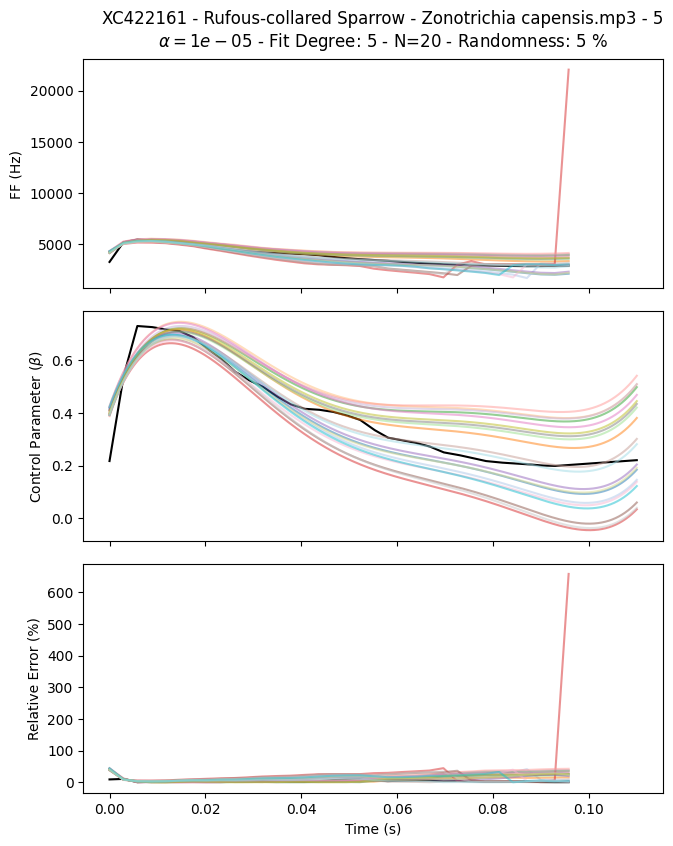

,ME (%),RMSE (Hz),params,alpha,id,file_name,mode,name,type,class_type,no_syllable,times
0,4.714567,233.262846,"[1690573.5686419194, -513849.8838455886, 57842...",0.00001,5_s0,5_s0.wav,fitting,XC422161,trill,1,5,"(9.03, 9.14)"
1,13.881016,544.445629,"[1690573.5686419194, -513849.8838455886, 57842...",0.00001,5_s1,5_s1.wav,fitting,XC422161,trill,1,5,"(9.03, 9.14)"
2,14.992664,603.020266,"[1690573.5686419194, -513849.8838455886, 57842...",0.00001,5_s2,5_s2.wav,fitting,XC422161,trill,1,5,"(9.03, 9.14)"
3,7.814896,351.205646,"[1690573.5686419194, -513849.8838455886, 57842...",0.00001,5_s3,5_s3.wav,fitting,XC422161,trill,1,5,"(9.03, 9.14)"
4,16.239388,671.060050,"[1690573.5686419194, -513849.8838455886, 57842...",0.00001,5_s4,5_s4.wav,fitting,XC422161,trill,1,5,"(9.03, 9.14)"
5,14.321818,610.691673,"[1690573.5686419194, -513849.8838455886, 57842...",0.00001,5_s5,5_s5.wav,fitting,XC422161,trill,1,5,"(9.03, 9.14)"
6,9.515942,416.418512,"[1690573.5686419194, -513849.8838455886, 57842...",0.00001,5_s6,5_s6.wav,fitting,XC422161,trill,1,5,"(9.03, 9.14)"
7,35.857548,3371.260132,"[1690573.5686419194, -513849.8838455886, 57842...",0.00001,5_s7,5_s7.wav,fitting,XC422161,trill,1,5,"(9.03, 9.14)"
8,16.802551,704.789833,"[1690573.5686419194, -513849.8838455886, 57842...",0.00001,5_s8,5_s8.wav,fitting,XC422161,trill,1,5,"(9.03, 9.14)"
9,11.575693,469.162940,"[1690573.5686419194, -513849.8838455886, 57842...",0.00001,5_s9,5_s9.wav,fitting,XC422161,trill,1,5,"(9.03, 9.14)"


Syllable 6: (9.17, 9.27) - Type: trill
Original song: XC422161 - No. Syllable: 6 - Type: trill


Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


Audio saved at assets/results/audios/augmented/XC422161/6_s0.wav.
Audio saved at assets/results/audios/augmented/XC422161/6_s1.wav.
Audio saved at assets/results/audios/augmented/XC422161/6_s2.wav.
Audio saved at assets/results/audios/augmented/XC422161/6_s3.wav.
Audio saved at assets/results/audios/augmented/XC422161/6_s4.wav.
Audio saved at assets/results/audios/augmented/XC422161/6_s5.wav.
Audio saved at assets/results/audios/augmented/XC422161/6_s6.wav.
Audio saved at assets/results/audios/augmented/XC422161/6_s7.wav.
Audio saved at assets/results/audios/augmented/XC422161/6_s8.wav.
Audio saved at assets/results/audios/augmented/XC422161/6_s9.wav.
Audio saved at assets/results/audios/augmented/XC422161/6_s10.wav.
Audio saved at assets/results/audios/augmented/XC422161/6_s11.wav.
Audio saved at assets/results/audios/augmented/XC422161/6_s12.wav.
Audio saved at assets/results/audios/augmented/XC422161/6_s13.wav.
Audio saved at assets/results/audios/augmented/XC422161/6_s14.wav.
Audio

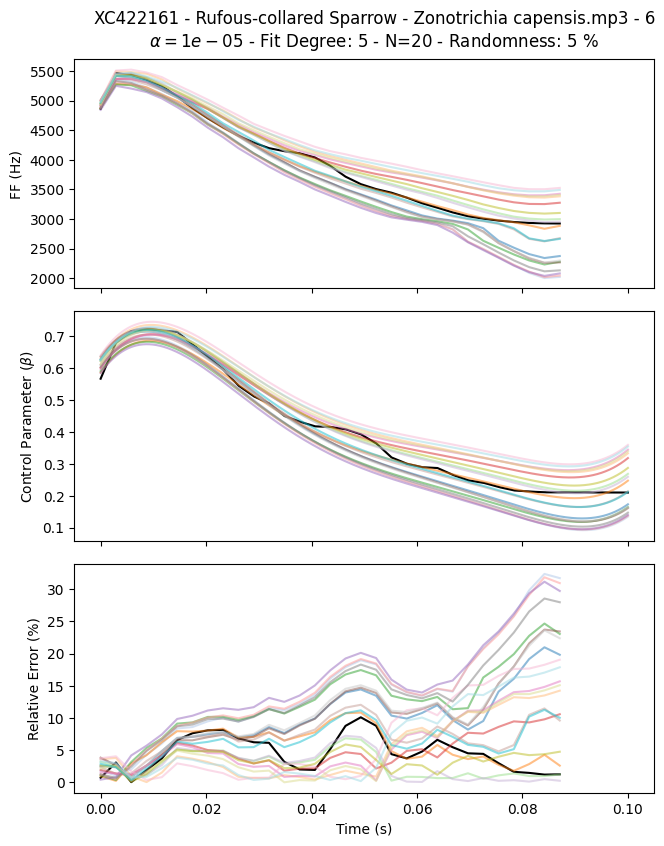

,ME (%),RMSE (Hz),params,alpha,id,file_name,mode,name,type,class_type,no_syllable,times
0,4.561035,230.799392,"[1443759.8060472924, -396169.06449719815, 4030...",0.00001,6_s0,6_s0.wav,fitting,XC422161,trill,1,6,"(9.17, 9.27)"
1,9.879201,399.540174,"[1443759.8060472924, -396169.06449719815, 4030...",0.00001,6_s1,6_s1.wav,fitting,XC422161,trill,1,6,"(9.17, 9.27)"
2,14.332477,575.891200,"[1443759.8060472924, -396169.06449719815, 4030...",0.00001,6_s2,6_s2.wav,fitting,XC422161,trill,1,6,"(9.17, 9.27)"
3,5.639612,275.373076,"[1443759.8060472924, -396169.06449719815, 4030...",0.00001,6_s3,6_s3.wav,fitting,XC422161,trill,1,6,"(9.17, 9.27)"
4,5.152996,227.923211,"[1443759.8060472924, -396169.06449719815, 4030...",0.00001,6_s4,6_s4.wav,fitting,XC422161,trill,1,6,"(9.17, 9.27)"
5,12.513290,505.570281,"[1443759.8060472924, -396169.06449719815, 4030...",0.00001,6_s5,6_s5.wav,fitting,XC422161,trill,1,6,"(9.17, 9.27)"
6,2.757447,152.849243,"[1443759.8060472924, -396169.06449719815, 4030...",0.00001,6_s6,6_s6.wav,fitting,XC422161,trill,1,6,"(9.17, 9.27)"
7,4.843522,201.871955,"[1443759.8060472924, -396169.06449719815, 4030...",0.00001,6_s7,6_s7.wav,fitting,XC422161,trill,1,6,"(9.17, 9.27)"
8,14.443068,580.370291,"[1443759.8060472924, -396169.06449719815, 4030...",0.00001,6_s8,6_s8.wav,fitting,XC422161,trill,1,6,"(9.17, 9.27)"
9,15.140321,607.518398,"[1443759.8060472924, -396169.06449719815, 4030...",0.00001,6_s9,6_s9.wav,fitting,XC422161,trill,1,6,"(9.17, 9.27)"


Syllable 7: (9.31, 9.41) - Type: trill
Original song: XC422161 - No. Syllable: 7 - Type: trill


Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


Audio saved at assets/results/audios/augmented/XC422161/7_s0.wav.
Audio saved at assets/results/audios/augmented/XC422161/7_s1.wav.
Audio saved at assets/results/audios/augmented/XC422161/7_s2.wav.
Audio saved at assets/results/audios/augmented/XC422161/7_s3.wav.
Audio saved at assets/results/audios/augmented/XC422161/7_s4.wav.
Audio saved at assets/results/audios/augmented/XC422161/7_s5.wav.
Audio saved at assets/results/audios/augmented/XC422161/7_s6.wav.
Audio saved at assets/results/audios/augmented/XC422161/7_s7.wav.
Audio saved at assets/results/audios/augmented/XC422161/7_s8.wav.
Audio saved at assets/results/audios/augmented/XC422161/7_s9.wav.
Audio saved at assets/results/audios/augmented/XC422161/7_s10.wav.
Audio saved at assets/results/audios/augmented/XC422161/7_s11.wav.
Audio saved at assets/results/audios/augmented/XC422161/7_s12.wav.
Audio saved at assets/results/audios/augmented/XC422161/7_s13.wav.
Audio saved at assets/results/audios/augmented/XC422161/7_s14.wav.
Audio

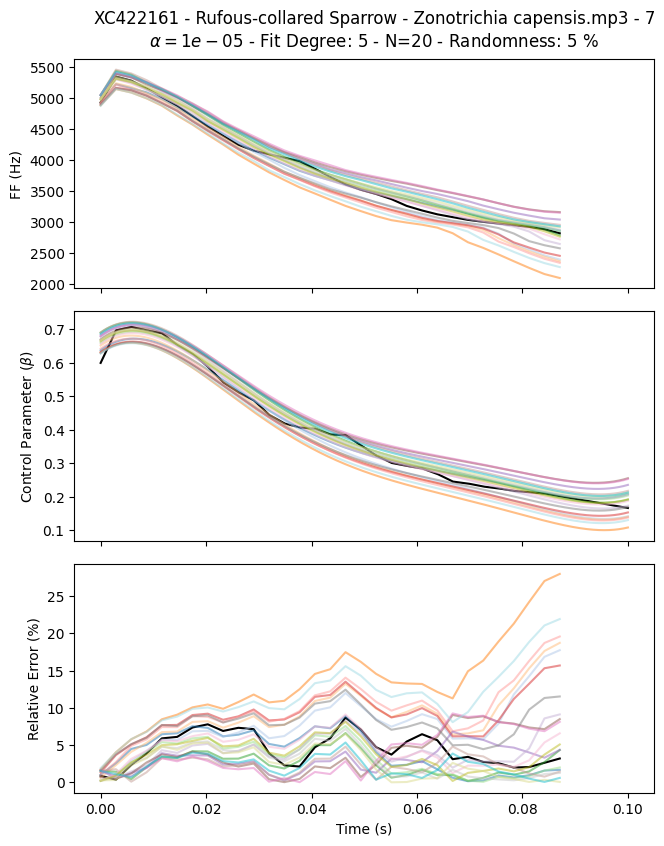

,ME (%),RMSE (Hz),params,alpha,id,file_name,mode,name,type,class_type,no_syllable,times
0,4.484009,214.213619,"[941407.0232122215, -264720.8509098947, 27224....",0.00001,7_s0,7_s0.wav,fitting,XC422161,trill,1,7,"(9.31, 9.41)"
1,4.115879,220.385266,"[941407.0232122215, -264720.8509098947, 27224....",0.00001,7_s1,7_s1.wav,fitting,XC422161,trill,1,7,"(9.31, 9.41)"
2,7.869568,316.644028,"[941407.0232122215, -264720.8509098947, 27224....",0.00001,7_s2,7_s2.wav,fitting,XC422161,trill,1,7,"(9.31, 9.41)"
3,13.405428,522.575743,"[941407.0232122215, -264720.8509098947, 27224....",0.00001,7_s3,7_s3.wav,fitting,XC422161,trill,1,7,"(9.31, 9.41)"
4,9.044447,361.474340,"[941407.0232122215, -264720.8509098947, 27224....",0.00001,7_s4,7_s4.wav,fitting,XC422161,trill,1,7,"(9.31, 9.41)"
5,2.537801,126.984853,"[941407.0232122215, -264720.8509098947, 27224....",0.00001,7_s5,7_s5.wav,fitting,XC422161,trill,1,7,"(9.31, 9.41)"
6,3.179676,173.083217,"[941407.0232122215, -264720.8509098947, 27224....",0.00001,7_s6,7_s6.wav,fitting,XC422161,trill,1,7,"(9.31, 9.41)"
7,9.064181,367.448126,"[941407.0232122215, -264720.8509098947, 27224....",0.00001,7_s7,7_s7.wav,fitting,XC422161,trill,1,7,"(9.31, 9.41)"
8,9.828851,391.269108,"[941407.0232122215, -264720.8509098947, 27224....",0.00001,7_s8,7_s8.wav,fitting,XC422161,trill,1,7,"(9.31, 9.41)"
9,3.114726,129.954851,"[941407.0232122215, -264720.8509098947, 27224....",0.00001,7_s9,7_s9.wav,fitting,XC422161,trill,1,7,"(9.31, 9.41)"


Syllable 8: (9.44, 9.54) - Type: trill
Original song: XC422161 - No. Syllable: 8 - Type: trill


Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


Audio saved at assets/results/audios/augmented/XC422161/8_s0.wav.
Audio saved at assets/results/audios/augmented/XC422161/8_s1.wav.
Audio saved at assets/results/audios/augmented/XC422161/8_s2.wav.
Audio saved at assets/results/audios/augmented/XC422161/8_s3.wav.
Audio saved at assets/results/audios/augmented/XC422161/8_s4.wav.
Audio saved at assets/results/audios/augmented/XC422161/8_s5.wav.
Audio saved at assets/results/audios/augmented/XC422161/8_s6.wav.
Audio saved at assets/results/audios/augmented/XC422161/8_s7.wav.
Audio saved at assets/results/audios/augmented/XC422161/8_s8.wav.
Audio saved at assets/results/audios/augmented/XC422161/8_s9.wav.
Audio saved at assets/results/audios/augmented/XC422161/8_s10.wav.
Audio saved at assets/results/audios/augmented/XC422161/8_s11.wav.
Audio saved at assets/results/audios/augmented/XC422161/8_s12.wav.
Audio saved at assets/results/audios/augmented/XC422161/8_s13.wav.
Audio saved at assets/results/audios/augmented/XC422161/8_s14.wav.
Audio

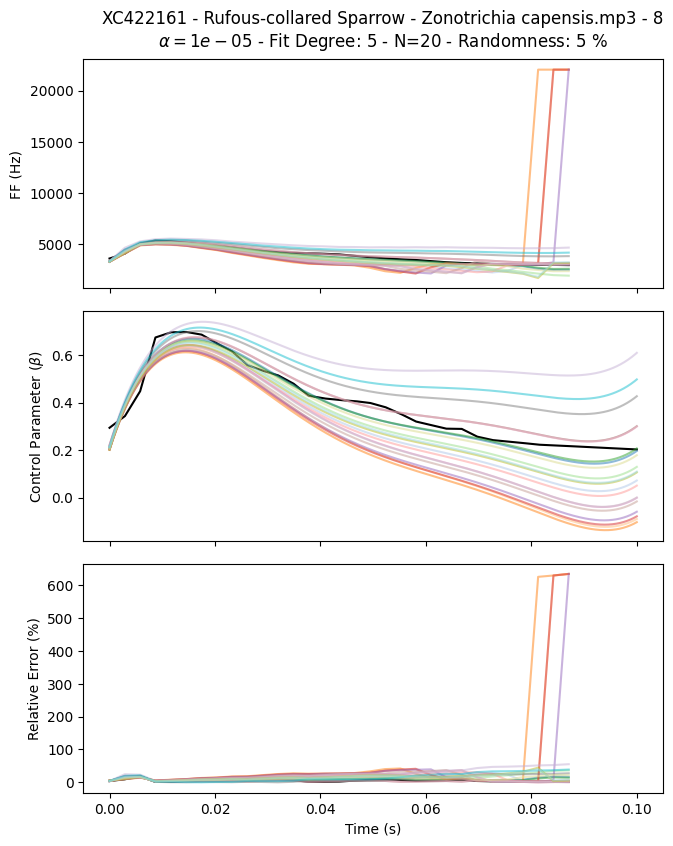

,ME (%),RMSE (Hz),params,alpha,id,file_name,mode,name,type,class_type,no_syllable,times
0,5.243869,265.746801,"[2579336.851420385, -737810.756907113, 78980.1...",0.00001,8_s0,8_s0.wav,fitting,XC422161,trill,1,8,"(9.44, 9.54)"
1,9.082922,382.586436,"[2579336.851420385, -737810.756907113, 78980.1...",0.00001,8_s1,8_s1.wav,fitting,XC422161,trill,1,8,"(9.44, 9.54)"
2,14.732637,645.519441,"[2579336.851420385, -737810.756907113, 78980.1...",0.00001,8_s2,8_s2.wav,fitting,XC422161,trill,1,8,"(9.44, 9.54)"
3,76.839608,5976.194322,"[2579336.851420385, -737810.756907113, 78980.1...",0.00001,8_s3,8_s3.wav,fitting,XC422161,trill,1,8,"(9.44, 9.54)"
4,56.564150,4900.515499,"[2579336.851420385, -737810.756907113, 78980.1...",0.00001,8_s4,8_s4.wav,fitting,XC422161,trill,1,8,"(9.44, 9.54)"
5,8.538607,357.918181,"[2579336.851420385, -737810.756907113, 78980.1...",0.00001,8_s5,8_s5.wav,fitting,XC422161,trill,1,8,"(9.44, 9.54)"
6,15.077276,604.562355,"[2579336.851420385, -737810.756907113, 78980.1...",0.00001,8_s6,8_s6.wav,fitting,XC422161,trill,1,8,"(9.44, 9.54)"
7,56.731503,4902.476541,"[2579336.851420385, -737810.756907113, 78980.1...",0.00001,8_s7,8_s7.wav,fitting,XC422161,trill,1,8,"(9.44, 9.54)"
8,15.027147,681.947962,"[2579336.851420385, -737810.756907113, 78980.1...",0.00001,8_s8,8_s8.wav,fitting,XC422161,trill,1,8,"(9.44, 9.54)"
9,36.820370,3515.715433,"[2579336.851420385, -737810.756907113, 78980.1...",0.00001,8_s9,8_s9.wav,fitting,XC422161,trill,1,8,"(9.44, 9.54)"


Syllable 9: (9.59, 9.68) - Type: trill
Original song: XC422161 - No. Syllable: 9 - Type: trill


Note: Illegal Audio-MPEG-Header 0x33292c20 at offset 257380.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


Audio saved at assets/results/audios/augmented/XC422161/9_s0.wav.
Audio saved at assets/results/audios/augmented/XC422161/9_s1.wav.
Audio saved at assets/results/audios/augmented/XC422161/9_s2.wav.
Audio saved at assets/results/audios/augmented/XC422161/9_s3.wav.
Audio saved at assets/results/audios/augmented/XC422161/9_s4.wav.
Audio saved at assets/results/audios/augmented/XC422161/9_s5.wav.
Audio saved at assets/results/audios/augmented/XC422161/9_s6.wav.
Audio saved at assets/results/audios/augmented/XC422161/9_s7.wav.
Audio saved at assets/results/audios/augmented/XC422161/9_s8.wav.
Audio saved at assets/results/audios/augmented/XC422161/9_s9.wav.
Audio saved at assets/results/audios/augmented/XC422161/9_s10.wav.
Audio saved at assets/results/audios/augmented/XC422161/9_s11.wav.
Audio saved at assets/results/audios/augmented/XC422161/9_s12.wav.
Audio saved at assets/results/audios/augmented/XC422161/9_s13.wav.
Audio saved at assets/results/audios/augmented/XC422161/9_s14.wav.
Audio

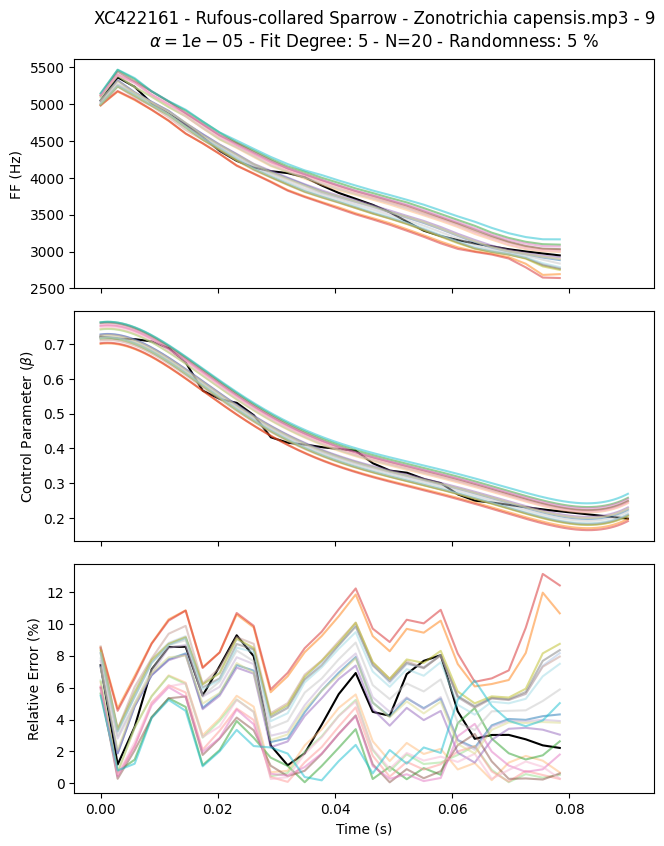

,ME (%),RMSE (Hz),params,alpha,id,file_name,mode,name,type,class_type,no_syllable,times
0,5.001379,250.881703,"[1546311.9709437191, -360045.05270537897, 2997...",0.00001,9_s0,9_s0.wav,fitting,XC422161,trill,1,9,"(9.59, 9.68)"
1,5.063989,239.468743,"[1546311.9709437191, -360045.05270537897, 2997...",0.00001,9_s1,9_s1.wav,fitting,XC422161,trill,1,9,"(9.59, 9.68)"
2,6.932607,304.773760,"[1546311.9709437191, -360045.05270537897, 2997...",0.00001,9_s2,9_s2.wav,fitting,XC422161,trill,1,9,"(9.59, 9.68)"
3,8.633316,368.694847,"[1546311.9709437191, -360045.05270537897, 2997...",0.00001,9_s3,9_s3.wav,fitting,XC422161,trill,1,9,"(9.59, 9.68)"
4,2.926278,169.549770,"[1546311.9709437191, -360045.05270537897, 2997...",0.00001,9_s4,9_s4.wav,fitting,XC422161,trill,1,9,"(9.59, 9.68)"
5,2.274345,127.519796,"[1546311.9709437191, -360045.05270537897, 2997...",0.00001,9_s5,9_s5.wav,fitting,XC422161,trill,1,9,"(9.59, 9.68)"
6,2.668975,163.965467,"[1546311.9709437191, -360045.05270537897, 2997...",0.00001,9_s6,9_s6.wav,fitting,XC422161,trill,1,9,"(9.59, 9.68)"
7,9.015222,379.803659,"[1546311.9709437191, -360045.05270537897, 2997...",0.00001,9_s7,9_s7.wav,fitting,XC422161,trill,1,9,"(9.59, 9.68)"
8,2.304350,145.883448,"[1546311.9709437191, -360045.05270537897, 2997...",0.00001,9_s8,9_s8.wav,fitting,XC422161,trill,1,9,"(9.59, 9.68)"
9,4.640675,229.280305,"[1546311.9709437191, -360045.05270537897, 2997...",0.00001,9_s9,9_s9.wav,fitting,XC422161,trill,1,9,"(9.59, 9.68)"


,ME (%),RMSE (Hz),params,alpha,id,file_name,mode,name,type,class_type,no_syllable,times
0,19.883212,752.991806,"[5658.295364106185, -4863.571994231476, 1577.5...",0.00001,0_s0,0_s0.wav,fitting,XC422161,theme,0,0,"(7.51, 7.79)"
1,24.631807,779.444579,"[5658.295364106185, -4863.571994231476, 1577.5...",0.00001,0_s1,0_s1.wav,fitting,XC422161,theme,0,0,"(7.51, 7.79)"
2,37.266206,1063.126591,"[5658.295364106185, -4863.571994231476, 1577.5...",0.00001,0_s2,0_s2.wav,fitting,XC422161,theme,0,0,"(7.51, 7.79)"
3,26.189015,797.348371,"[5658.295364106185, -4863.571994231476, 1577.5...",0.00001,0_s3,0_s3.wav,fitting,XC422161,theme,0,0,"(7.51, 7.79)"
4,23.588087,775.028074,"[5658.295364106185, -4863.571994231476, 1577.5...",0.00001,0_s4,0_s4.wav,fitting,XC422161,theme,0,0,"(7.51, 7.79)"
...,...,...,...,...,...,...,...,...,...,...,...,...
205,5.945521,271.448734,"[1546311.9709437191, -360045.05270537897, 2997...",0.00001,9_s16,9_s16.wav,fitting,XC422161,trill,1,9,"(9.59, 9.68)"
206,7.081587,308.382227,"[1546311.9709437191, -360045.05270537897, 2997...",0.00001,9_s17,9_s17.wav,fitting,XC422161,trill,1,9,"(9.59, 9.68)"
207,4.996713,239.012705,"[1546311.9709437191, -360045.05270537897, 2997...",0.00001,9_s18,9_s18.wav,fitting,XC422161,trill,1,9,"(9.59, 9.68)"
208,2.849019,137.833714,"[1546311.9709437191, -360045.05270537897, 2997...",0.00001,9_s19,9_s19.wav,fitting,XC422161,trill,1,9,"(9.59, 9.68)"


Computation time for augmenting data: 32.30 min  for 10 syllables fo the audio file XC422161 - Rufous-collared Sparrow - Zonotrichia capensis.mp3  generating 20 samples per each syllable. Method used fitting. Random percentage 5% varying 2 parameters.


In [4]:
alpha_0 = 1e-5
model = Model(ovsr=10)

df_results = augmente_data(btv_0, model, metadata,
                           alpha_0=alpha_0, mode="fitting",
                           N=20, beta_N=30, poly_deg_beta=5, random_per=5, no_params=2,
                           umbral_FF=1.4, n_fft=512, ff_method="yin",
                           verbose=True, plot=True, save_audio=True, save_df=True)

In [ ]:
# Fit the fundamental frequency from the selected syllable
# plot.fittings_comparison(btv_0, verbose=True)

In [ ]:
# Alpha value given
alpha_0 = 1e-5
model = Model(ovsr=10)
beta_optimal = optimal_beta_curve(btv_0, model, alpha_0=alpha_0, 
                                  beta_N=10, plot=False, poly_deg=5)

In [ ]:
# Best syllable found using the optimal beta and defined alpha0
# Create synthetic syllable and 
duration = btv_0.time_s[-1]
synthetic = Synthetic(duration=duration, proj_dirs=proj_dirs)
synthetic.initialize()

alpha = gaussian(synthetic.time_s, alpha_0, duration/2, sigma=0.1)
synthetized = model.motor_gesture(synthetic, curves=[alpha, beta_optimal])
synthetized.acoustical_features(umbral_FF=1.0, n_fft=512, ff_method="yin")

# Plot the motor gesture and waveform and spectrogram generated
_ = plotter.alpha_beta(synthetized, save=False)
_ = plotter.spectrogram(synthetized, save=False, ff=True)

# Play the synthetized syllable
synthetized.play()

In [ ]:
# plot.fittings_comparison(synthetized.time, synthetized.ff, verbose=True, variable="Fundamental Frequency")
# plot.fittings_comparison(synthetized.time_s, synthetized.beta, verbose=True, variable=r"Control Parameter ($\beta$)", unit="a.u.")

In [ ]:
# from matplotlib import pyplot as plt


# plt.figure()
# N = synthetized.s.shape[0]
# sr = synthetized.sr  # Sampling rate
# fft_abs = np.abs(np.fft.fft(synthetized.s))
# freqs = np.fft.fftfreq(N, d=1/sr)
# plt.plot(freqs[:N//2], np.log10(1e-8 + fft_abs[:N//2]))  # Plot only the positive frequencies
# plt.xlabel("Frequency (Hz)")
# plt.ylabel("|FFT|")
# plt.title(fr"Log10 Magnitude Spectrum - $\alpha={alpha_0}$")
# plt.show()

In [ ]:
# [btv_0.metadata[k] for k in btv_0.metadata.keys()]#, "class_type", "no_syllable"]

In [ ]:
syllables_df_synth = augmente_beta(btv_0, model, beta_optimal, alpha_0=alpha_0,
                                   mode="composition",
                                   N=10, random_per=5, no_params=2, plot=True)

In [ ]:
syllables_df = augmente_beta(btv_0, model, beta_optimal, alpha_0=alpha_0,
                              mode="fitting",
                              N=5, random_per=10, no_params=2, plot=True)

In [ ]:
#.strip("()").split(",")

In [ ]:
df_results

In [ ]:
# Revocer a synthetic syllable from the synthetized dataframe
sr = 44100
index = 7
model = Model(ovsr=10)
times = df_results.iloc[index]["times"]#.strip("()").split(",")

duration = times[1] - times[0] # btv_0.time_s[-1]
synthetic = Synthetic(duration=duration, proj_dirs=proj_dirs, sr=sr)
synthetic.initialize()

alpha_0 = df_results.iloc[index]["alpha"]
beta = np.polyval(df_results.iloc[index]["params"], synthetic.time_s) 
# composition
alpha = gaussian(synthetic.time_s, alpha_0, duration/2, sigma=0.1, a1=-0.1*alpha_0) # alpha 

synthetized = model.motor_gesture(synthetic, [alpha, beta])
synthetized.acoustical_features(umbral_FF=1.0, n_fft=512, ff_method="yin")
synthetized.file_name = df_results.iloc[index]["file_name"][:-4]
# Plot the motor gesture and waveform and spectrogram generated
_ = plotter.alpha_beta(synthetized, save=False)
_ = plotter.spectrogram(synthetized, save=False, ff=True)

# Play the synthetized syllable
synthetized.play()

In [ ]:
alpha_0

In [ ]:
# PARA KAGGLE
import numpy as np
import librosa
from scipy.ndimage import zoom
import torch

def _resize_to(S, target_shape):
    f, t = S.shape
    tf, tt = target_shape
    if (f, t) == (tf, tt):
        return S
    return zoom(S, (tf / f, tt / t), order=1)  # bilinear-ish

def spectrogram_stack(y, sr,
                      n_fft=1024, hop_length=256, n_mels=128,
                      target_shape=(128, 256)):
    # compute a few complementary TF representations
    # 1) linear-STFT magnitude (dB)
    S1 = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length))
    S1 = librosa.amplitude_to_db(S1, ref=np.max)

    # 2) mel spectrogram (dB)
    M = librosa.feature.melspectrogram(y, sr=sr, n_fft=n_fft,
                                       hop_length=hop_length, n_mels=n_mels)
    M_db = librosa.power_to_db(M, ref=np.max)

    # 3) log-mel delta (first derivative)
    M_delta = librosa.feature.delta(M_db)

    # 4) spectral contrast (another complementary descriptor)
    C = librosa.feature.spectral_contrast(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)

    # choose/resample each to the same target (F, T)
    S1_r = _resize_to(S1, target_shape)
    M_db_r = _resize_to(M_db, target_shape)
    M_delta_r = _resize_to(M_delta, target_shape)
    C_r = _resize_to(C, target_shape)

    # stack channels: shape (C, F, T)
    stack = np.stack([S1_r, M_db_r, M_delta_r, C_r], axis=0).astype(np.float32)

    # normalization per-channel (optional but recommended)
    mean = stack.mean(axis=(1, 2), keepdims=True)
    std = stack.std(axis=(1, 2), keepdims=True) + 1e-8
    stack = (stack - mean) / std

    return stack

# convert to torch tensor and add batch dim
y, sr = librosa.load("audio.wav", sr=44100)
stack = spectrogram_stack(y, sr, target_shape=(128, 256))  # (C,F,T)
x = torch.from_numpy(stack)           # shape (C,F,T)
x = x.unsqueeze(0)                    # shape (B,C,F,T) for CNN training